# E-Commerce Sales — Exploratory Data Analysis

## CodeAlpha Data Analytics Internship — Task 2

This notebook performs a complete Exploratory Data Analysis (EDA) of the supplied e-commerce sales dataset, including data understanding, cleaning, descriptive statistics, sales/product/category/region/profit analysis, correlation analysis, visualizations, and business insights.

**Dataset:** `ecommerce_sales_raw.csv`


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

DATA_FILE = 'ecommerce_sales_raw.csv'
df = pd.read_csv(DATA_FILE)
print('Dataset loaded successfully')
print('Shape:', df.shape)
df.head()

Dataset loaded successfully
Shape: (3004, 12)


,Order ID,Order Date,Customer ID,Category,Sub-Category,Product,Region,Quantity,Unit Price,Discount,Sales,Profit
0,ORD00001,2025-06-10,CUST0421,Electronics,Headphones,Headphones Product 8,East,4,98.28,0.10,353.81,26.12
1,ORD00002,2025-03-08,CUST0741,Accessories,Keyboards,Keyboards Product 7,East,4,59.68,0.05,226.78,32.13
2,ORD00003,2025-06-11,CUST0686,Furniture,Desks,Desks Product 7,South,3,34.52,0.05,98.38,7.90
3,ORD00004,2025-09-05,CUST0622,Office Supplies,Paper,Paper Product 7,North,4,38.76,0.20,124.03,25.88
4,ORD00005,2025-01-16,CUST0293,Furniture,Tables,Tables Product 8,South,3,78.91,0.10,213.06,43.45


## 1. Data Understanding


In [2]:
print('Rows:', df.shape[0])
print('Columns:', df.shape[1])
print('\nColumns:')
print(df.columns.tolist())
print('\nData types:')
print(df.dtypes)
print('\nDataset information:')
df.info()


Rows: 3004
Columns: 12

Columns:
['Order ID', 'Order Date', 'Customer ID', 'Category', 'Sub-Category', 'Product', 'Region', 'Quantity', 'Unit Price', 'Discount', 'Sales', 'Profit']

Data types:
Order ID         object
Order Date       object
Customer ID      object
Category         object
Sub-Category     object
Product          object
Region           object
Quantity          int64
Unit Price      float64
Discount        float64
Sales           float64
Profit          float64
dtype: object

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3004 entries, 0 to 3003
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order ID      3004 non-null   object 
 1   Order Date    3004 non-null   object 
 2   Customer ID   3004 non-null   object 
 3   Category      3004 non-null   object 
 4   Sub-Category  3004 non-null   object 
 5   Product       3004 non-null   object 
 6   Region        3004 non-nul

In [3]:
print('Missing values:')
display(df.isna().sum().to_frame('Missing Values'))
print('Duplicate rows:', df.duplicated().sum())
print('\nDescriptive statistics:')
display(df.describe(include='all').T)

Missing values:


,Missing Values
Order ID,0
Order Date,0
Customer ID,0
Category,0
Sub-Category,0
Product,0
Region,0
Quantity,0
Unit Price,0
Discount,15


Duplicate rows: 4

Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order ID,3004,3000,ORD00001,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,3004,365,2025-04-23,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,3004,781,CUST0124,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,3004,4,Furniture,769,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sub-Category,3004,12,Paper,279,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product,3004,96,Paper Product 3,47,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,3004,4,East,776,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,"3,004.00",NaN,NaN,NaN,2.99,1.42,1.00,2.00,3.00,4.00,5.00
Unit Price,"3,004.00",NaN,NaN,NaN,75.18,55.18,5.63,38.52,59.87,94.52,569.71
Discount,"2,989.00",NaN,NaN,NaN,0.06,0.07,0.00,0.00,0.05,0.10,0.20


## 2. Data Cleaning


In [4]:
data = df.copy()

# Convert date and numeric fields
data['Order Date'] = pd.to_datetime(data['Order Date'], errors='coerce')
numeric_cols = ['Quantity', 'Unit Price', 'Discount', 'Sales', 'Profit']
for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Remove exact duplicates
before = len(data)
data = data.drop_duplicates().copy()

# Fill missing numeric values with medians; categorical values with mode
for col in numeric_cols:
    if data[col].isna().any():
        data[col] = data[col].fillna(data[col].median())
for col in data.select_dtypes(include='object').columns:
    if data[col].isna().any():
        data[col] = data[col].fillna(data[col].mode()[0])

print('Duplicate rows removed:', before - len(data))
print('Cleaned shape:', data.shape)
print('Remaining missing values:', int(data.isna().sum().sum()))
display(data.head())

Duplicate rows removed: 4
Cleaned shape: (3000, 12)
Remaining missing values: 0


,Order ID,Order Date,Customer ID,Category,Sub-Category,Product,Region,Quantity,Unit Price,Discount,Sales,Profit
0,ORD00001,2025-06-10,CUST0421,Electronics,Headphones,Headphones Product 8,East,4,98.28,0.10,353.81,26.12
1,ORD00002,2025-03-08,CUST0741,Accessories,Keyboards,Keyboards Product 7,East,4,59.68,0.05,226.78,32.13
2,ORD00003,2025-06-11,CUST0686,Furniture,Desks,Desks Product 7,South,3,34.52,0.05,98.38,7.90
3,ORD00004,2025-09-05,CUST0622,Office Supplies,Paper,Paper Product 7,North,4,38.76,0.20,124.03,25.88
4,ORD00005,2025-01-16,CUST0293,Furniture,Tables,Tables Product 8,South,3,78.91,0.10,213.06,43.45


## 3. Sales Analysis


In [5]:
total_sales = data['Sales'].sum()
total_profit = data['Profit'].sum()
total_orders = data['Order ID'].nunique()
total_quantity = data['Quantity'].sum()
avg_order_sales = data.groupby('Order ID')['Sales'].sum().mean()

print(f'Total Sales: ${total_sales:,.2f}')
print(f'Total Profit: ${total_profit:,.2f}')
print(f'Total Orders: {total_orders:,}')
print(f'Total Quantity Sold: {total_quantity:,}')
print(f'Average Sales per Order: ${avg_order_sales:,.2f}')


Total Sales: $631,035.21
Total Profit: $104,853.57
Total Orders: 3,000
Total Quantity Sold: 8,972
Average Sales per Order: $210.35


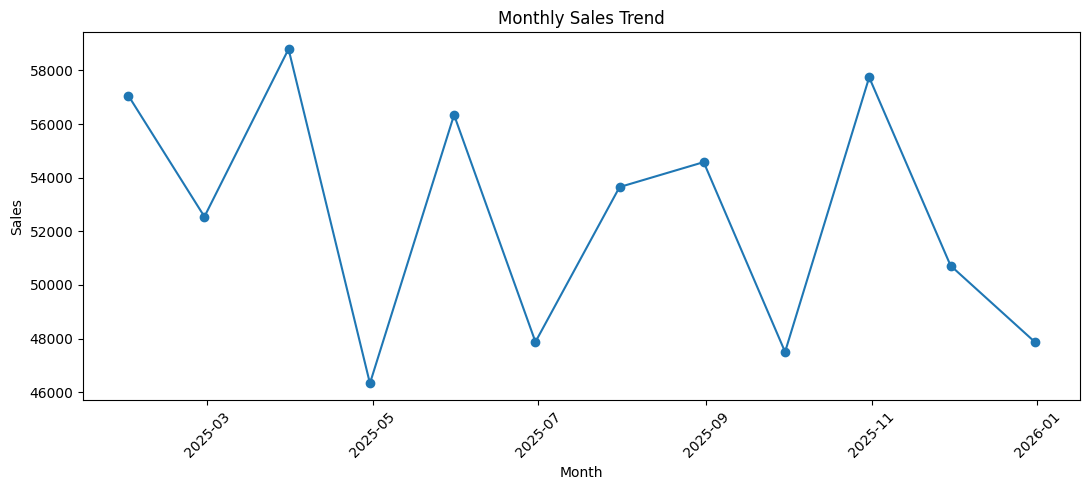

In [6]:
monthly_sales = data.set_index('Order Date').resample('ME')['Sales'].sum()
plt.figure(figsize=(11,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Product and Category Analysis


,Sales,Profit,Quantity
Category,,,
Office Supplies,"163,136.87","26,998.55",2282
Furniture,"160,891.37","27,222.10",2345
Accessories,"155,381.85","25,868.70",2175
Electronics,"151,625.12","24,764.22",2170


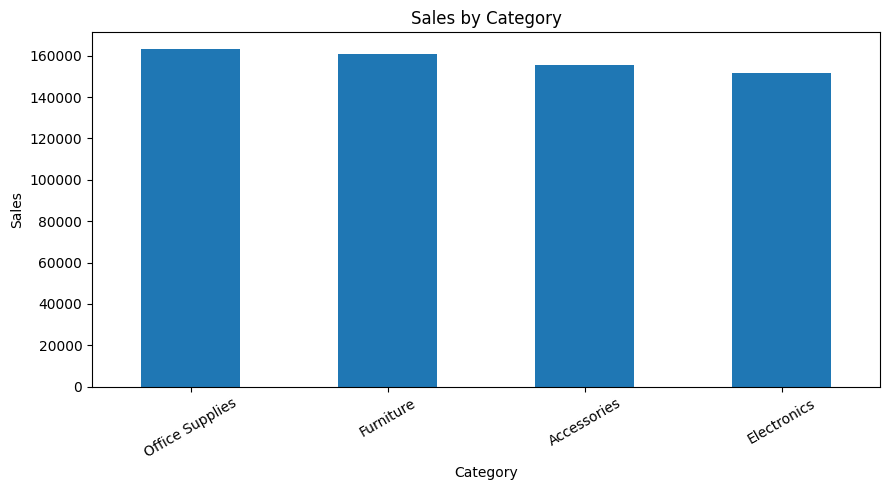

In [7]:
category_summary = data.groupby('Category').agg(
    Sales=('Sales','sum'), Profit=('Profit','sum'), Quantity=('Quantity','sum')
).sort_values('Sales', ascending=False)
display(category_summary)

plt.figure(figsize=(9,5))
category_summary['Sales'].plot(kind='bar')
plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Top 10 products by sales:


,Sales,Profit,Quantity
Product,,,
Paper Product 3,"13,113.76","2,216.74",159
Chairs Product 2,"10,732.57","1,814.80",137
Paper Product 6,"10,141.11","1,445.84",135
Desks Product 7,"9,664.61","1,445.47",124
Keyboards Product 5,"9,463.56","1,603.31",130
Cables Product 3,"8,963.61","1,626.84",102
Headphones Product 5,"8,855.88","1,353.65",130
Paper Product 7,"8,750.13","1,414.69",91
Storage Product 7,"8,738.61","1,396.51",114


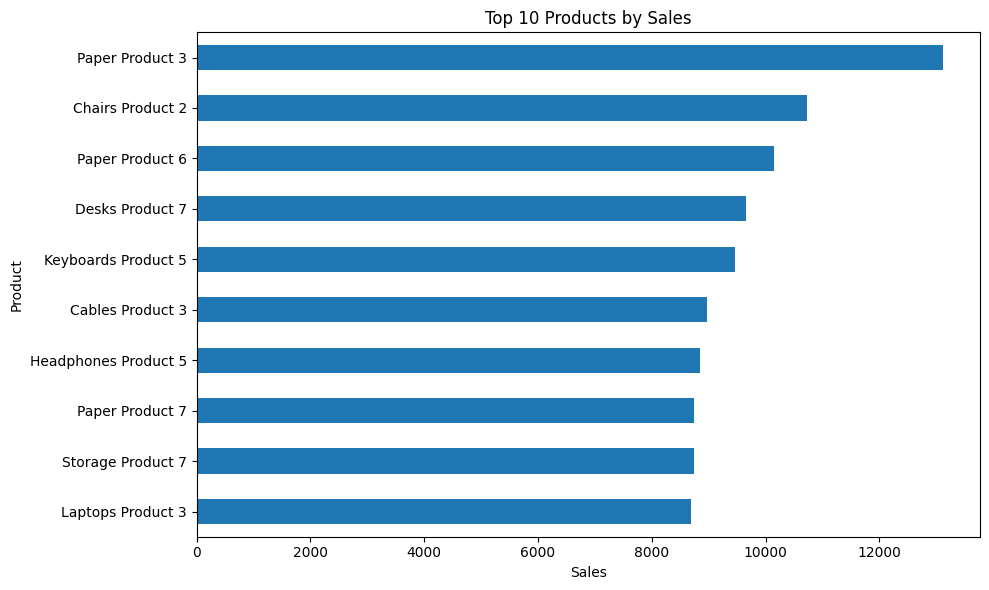

In [8]:
top_products = data.groupby('Product').agg(
    Sales=('Sales','sum'), Profit=('Profit','sum'), Quantity=('Quantity','sum')
).sort_values('Sales', ascending=False).head(10)
print('Top 10 products by sales:')
display(top_products)

plt.figure(figsize=(10,6))
top_products['Sales'].sort_values().plot(kind='barh')
plt.title('Top 10 Products by Sales')
plt.xlabel('Sales')
plt.tight_layout()
plt.show()

## 5. Regional Analysis


,Sales,Profit,Quantity
Region,,,
East,"162,576.78","27,913.93",2273
West,"161,213.13","26,316.36",2269
North,"157,338.77","25,450.03",2263
South,"149,906.53","25,173.25",2167


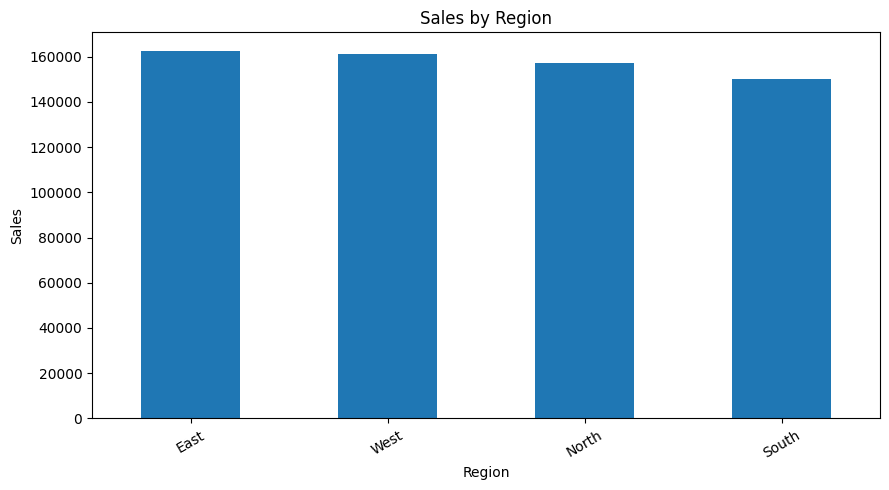

In [9]:
region_summary = data.groupby('Region').agg(
    Sales=('Sales','sum'), Profit=('Profit','sum'), Quantity=('Quantity','sum')
).sort_values('Sales', ascending=False)
display(region_summary)

plt.figure(figsize=(9,5))
region_summary['Sales'].plot(kind='bar')
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 6. Profitability and Discount Analysis


,Sales,Profit,Orders
Discount,,,
0.00,"264,557.67","47,821.22",1189
0.05,"147,994.02","24,800.77",665
0.10,"100,311.65","15,523.37",489
0.15,"80,016.09","11,952.12",425
0.20,"38,155.78","4,756.09",232


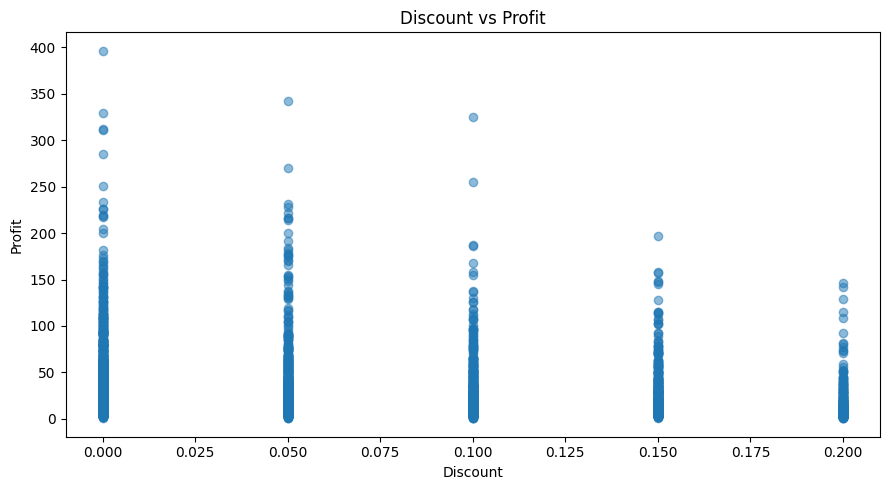

In [10]:
discount_summary = data.groupby('Discount').agg(
    Sales=('Sales','sum'), Profit=('Profit','sum'), Orders=('Order ID','nunique')
).sort_index()
display(discount_summary)

plt.figure(figsize=(9,5))
plt.scatter(data['Discount'], data['Profit'], alpha=0.5)
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

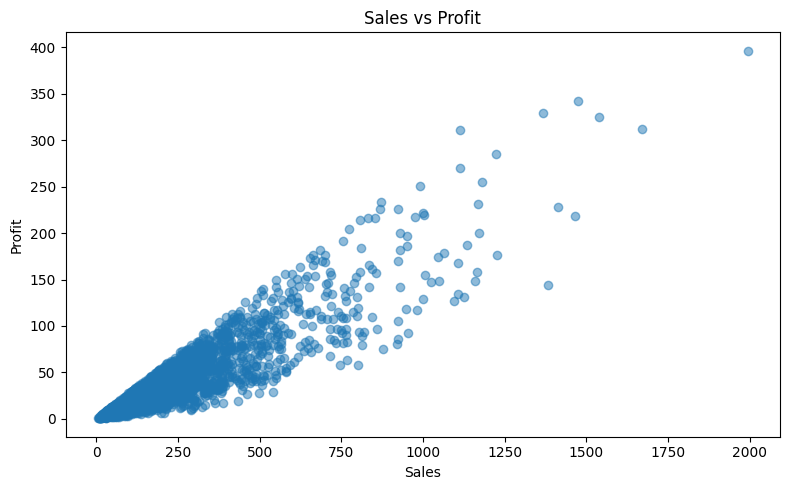

In [11]:
plt.figure(figsize=(8,5))
plt.scatter(data['Sales'], data['Profit'], alpha=0.5)
plt.title('Sales vs Profit')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()


## 7. Correlation Analysis


,Quantity,Unit Price,Discount,Sales,Profit
Quantity,1.00,-0.00,0.00,0.50,0.44
Unit Price,-0.00,1.00,-0.03,0.77,0.70
Discount,0.00,-0.03,1.00,-0.09,-0.16
Sales,0.50,0.77,-0.09,1.00,0.91
Profit,0.44,0.70,-0.16,0.91,1.00


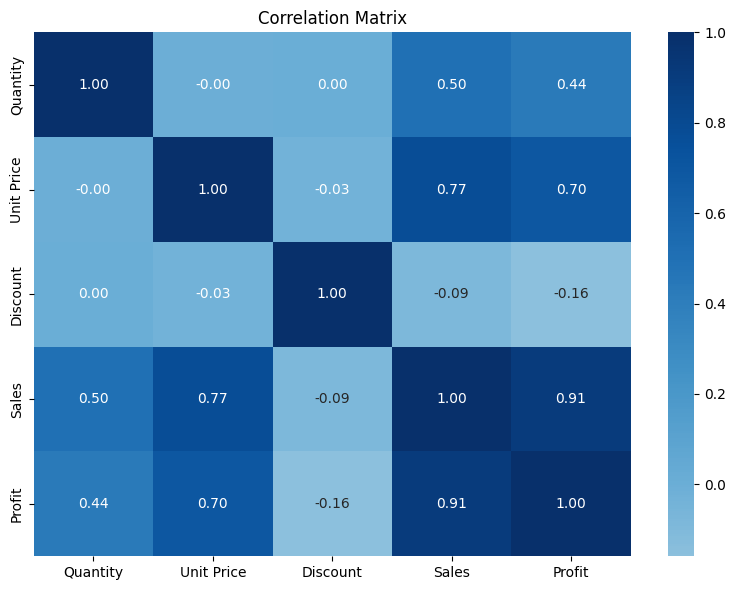

In [12]:
corr_cols = ['Quantity','Unit Price','Discount','Sales','Profit']
corr = data[corr_cols].corr()
display(corr)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## 8. Key Business Insights


In [13]:
best_category = category_summary['Sales'].idxmax()
best_region = region_summary['Sales'].idxmax()
best_product = top_products.index[0]
most_profitable_category = category_summary['Profit'].idxmax()
print(f'1. Highest-sales category: {best_category}')
print(f'2. Highest-sales region: {best_region}')
print(f'3. Top product by sales: {best_product}')
print(f'4. Most profitable category: {most_profitable_category}')
print(f'5. Overall profit margin: {(total_profit / total_sales * 100):.2f}%')

print('\nRecommendations:')
print('- Focus inventory and marketing on the strongest categories and products.')
print('- Compare regional performance to identify growth opportunities in weaker regions.')
print('- Monitor discount levels carefully because discounting can affect profitability.')
print('- Track monthly sales trends to support demand planning and campaign timing.')

1. Highest-sales category: Office Supplies
2. Highest-sales region: East
3. Top product by sales: Paper Product 3
4. Most profitable category: Furniture
5. Overall profit margin: 16.62%

Recommendations:
- Focus inventory and marketing on the strongest categories and products.
- Compare regional performance to identify growth opportunities in weaker regions.
- Monitor discount levels carefully because discounting can affect profitability.
- Track monthly sales trends to support demand planning and campaign timing.


## Conclusion

The EDA provides a structured view of e-commerce sales performance across time, products, categories, regions, discounts, and profitability. The findings can support better inventory planning, marketing decisions, regional strategy, and profit-focused pricing decisions.
